# TensorBoard-Plots der Big Random Search: gemeinsame Configs

Dieses Notebook wertet den direkten Vergleich zwischen `Pretrained` und `Fully-Joint` aus.
Es werden nur Runs verwendet, deren vergleichbare Hyperparameter-Konfiguration in beiden Varianten exakt vorkommt.

- `no_aux` als **Pretrained**
- `additive` als **Fully-Joint**

Variantenspezifische Unterschiede wie Checkpoint-Initialisierung, Auxiliary-Loss und maximale Trainingsdauer sind nicht Teil des Vergleichsschlüssels. Die Kurvenplots werden nicht gekürzt, damit unterschiedliche Trainingsdauern sichtbar bleiben.

Die Abbildungen werden im einheitlichen Stil der Masterarbeit als PDF gespeichert.


In [ ]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, MultipleLocator, PercentFormatter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
})

# Zwei Varianten nebeneinander: volle Textbreite.
FIGSIZE_PAIR = (6.8, 2.8)
# 2 x 3 Vergleichsmatrix: volle Textbreite.
FIGSIZE_GRID = (6.8, 4.6)
# Experten-Grid braucht links mehr Platz fuer die Variantenlabels.
FIGSIZE_GRID_EXPERT = (9.5, 4.6)
EXPERT_GRID_LEFT = 0.14
EXPERT_ROW_LABEL_X = 0.085
# Einzelplots werden typischerweise mit ca. 0.7\linewidth eingebunden.
FIGSIZE_SINGLE = (3.6, 2.3)
# Balkendiagramm mit 14 gemeinsamen Konfigurationen.
FIGSIZE_BAR = (6.8, 2.5)


In [17]:
RUN_DIR_NAME = "big_randomsearch"
OUT_DIR_NAME = "figures_big_randomsearch"
MAX_EPOCH = None

VARIANTEN = [
    ("no_aux", "Pretrained"),
    ("additive", "Fully-Joint"),
]
MATCH_VARIANTS = [label for _, label in VARIANTEN]

CONFIG_KEY_COLUMNS = [
    "trial",
    "seed",
    "expert_lr",
    "rejector_lr",
    "weight_decay",
    "budget_loss_weight",
    "routing_loss_weight",
    "temperature",
    "topk_noise_std",
    "topk_noise_start_epoch",
    "topk_noise_epochs",
    "batch_size",
    "threshold_r1",
    "threshold_r2",
]


def finde_moe_root() -> Path:
    # Findet den moe-Ordner, egal ob das Notebook aus dem Repo-Root oder aus moe/plots gestartet wird.
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        kandidaten = (
            base,
            base / "moe",
            base / "single_pulse_classifier_training" / "moe",
            base / "WP2-1" / "single_pulse_classifier_training" / "moe",
        )
        for kandidat in kandidaten:
            if (kandidat / "moe_runs" / RUN_DIR_NAME).exists():
                return kandidat
    raise FileNotFoundError(f"moe_runs/{RUN_DIR_NAME} konnte vom aktuellen Arbeitsverzeichnis aus nicht gefunden werden.")


MOE_ROOT = finde_moe_root()
RUN_ROOT = MOE_ROOT / "moe_runs" / RUN_DIR_NAME
OUT_DIR = MOE_ROOT / "plots" / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ROOT, OUT_DIR


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/big_randomsearch'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch'))

In [18]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        warnings.warn(f"Konnte JSON nicht lesen: {path}")
        return {}


def dekodiere_float_token(token: str) -> str:
    return token.replace("p", ".").replace("em", "e-")


def parse_run_name(run_name: str) -> dict:
    muster = {
        "trial": r"trial(\d+)",
        "seed": r"seed(\d+)",
        "expert_lr": r"expertlr([0-9pem]+)",
        "rejector_lr": r"rejectorlr([0-9pem]+)",
        "weight_decay": r"wd([0-9pem]+)",
        "temperature": r"temp([0-9pem]+)",
        "topk_noise_std": r"topknoisestd([0-9pem]+)",
        "topk_noise_start_epoch": r"noisestart(\d+)",
        "topk_noise_epochs": r"noiseep(\d+)",
        "budget": r"budget([0-9pem]+)",
        "routing": r"routing([0-9pem]+)",
        "aux": r"aux([0-9pem]+)",
        "aux_warmup": r"auxwarmup(\d+)",
    }
    daten = {}
    for name, pattern in muster.items():
        match = re.search(pattern, run_name)
        if not match:
            daten[name] = np.nan
            continue
        value = match.group(1)
        if name in {"trial", "seed", "aux_warmup", "topk_noise_start_epoch", "topk_noise_epochs"}:
            daten[name] = int(value)
        else:
            daten[name] = float(dekodiere_float_token(value))
    return daten


def nested_get(daten: dict, keys: tuple[str, ...], default=np.nan):
    current = daten
    for key in keys:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def canonical_number(value):
    if value is None:
        return np.nan
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def normalize_config_value(value):
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, (np.floating, float)):
        return format(float(value), ".17g")
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def make_config_key(row: pd.Series) -> str:
    return json.dumps(
        {column: normalize_config_value(row[column]) for column in CONFIG_KEY_COLUMNS},
        sort_keys=True,
        separators=(",", ":"),
    )


def kurzer_run_name(run: str) -> str:
    parsed = parse_run_name(run)
    teile = []
    if not math.isnan(parsed.get("trial", np.nan)):
        teile.append(f"t{int(parsed['trial'])}")
    if not math.isnan(parsed.get("seed", np.nan)):
        teile.append(f"s{int(parsed['seed'])}")
    if not math.isnan(parsed.get("routing", np.nan)):
        teile.append(f"r{parsed['routing']:g}")
    if not math.isnan(parsed.get("budget", np.nan)):
        teile.append(f"b{parsed['budget']:g}")
    return "_".join(teile) if teile else run[:45]


def safe_name(text: str) -> str:
    return text.lower().replace("-", "_").replace(" ", "_")


def speichere_abbildung(fig, name: str, extra_artists=()):
    path = OUT_DIR / f"{Path(name).stem}.pdf"
    bbox_extra_artists = tuple(fig.legends) + tuple(extra_artists)
    fig.savefig(
        path,
        bbox_inches="tight",
        bbox_extra_artists=bbox_extra_artists,
        pad_inches=0.08,
    )
    print(path)


In [ ]:
def bool_eq(value, expected: bool) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and np.isnan(value):
        return False
    return bool(value) is expected


def is_canonical_variant_run(row: pd.Series) -> bool:
    if row["variant"] == "Pretrained":
        return (
            row["expert_aux_loss_epochs"] == 0
            and bool_eq(row["only_aux_warmup"], True)
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    if row["variant"] == "Fully-Joint":
        return (
            row["expert_aux_loss_weight"] == 1.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["aux_loss_mode"] == "additive"
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    return False


def load_tensorboard_scalars(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    scalar_rows = []
    run_rows = []

    for folder, label in VARIANTEN:
        variant_root = run_root / folder
        if not variant_root.exists():
            warnings.warn(f"Variante fehlt: {variant_root}")
            continue

        for tensorboard_dir in sorted(variant_root.glob("*/tensorboard")):
            run_dir = tensorboard_dir.parent
            event_files = sorted(tensorboard_dir.glob("events.out.tfevents.*"))
            if not event_files:
                continue

            try:
                acc = EventAccumulator(str(tensorboard_dir), size_guidance={"scalars": 0})
                acc.Reload()
            except Exception as exc:
                warnings.warn(f"TensorBoard-Run konnte nicht gelesen werden: {tensorboard_dir} ({exc})")
                continue

            tags = set(acc.Tags().get("scalars", []))
            parsed = parse_run_name(run_dir.name)
            cfg = read_json(run_dir / "sampled_config.json")
            training = cfg.get("training", {})
            model = cfg.get("model", {})
            loader = cfg.get("loader", {})
            inference = cfg.get("inference", {})
            run_id = f"{folder}/{run_dir.name}"
            n_points = 0

            for tag in sorted(tags):
                for event in acc.Scalars(tag):
                    scalar_rows.append({
                        "variant_folder": folder,
                        "variant": label,
                        "run_id": run_id,
                        "run": run_dir.name,
                        "run_dir": str(run_dir),
                        "tag": tag,
                        "step": event.step,
                        "value": event.value,
                        "wall_time": event.wall_time,
                    })
                    n_points += 1

            run_rows.append({
                "variant_folder": folder,
                "variant": label,
                "run_id": run_id,
                "run": run_dir.name,
                "run_dir": str(run_dir),
                "short_name": kurzer_run_name(run_dir.name),
                "n_points": n_points,
                "trial": canonical_number(parsed.get("trial")),
                "seed": canonical_number(cfg.get("seed", parsed.get("seed"))),
                "expert_lr": canonical_number(training.get("expert_learning_rate", parsed.get("expert_lr"))),
                "rejector_lr": canonical_number(training.get("rejector_learning_rate", parsed.get("rejector_lr"))),
                "weight_decay": canonical_number(training.get("weight_decay", parsed.get("weight_decay"))),
                "budget_loss_weight": canonical_number(training.get("budget_loss_weight", parsed.get("budget"))),
                "routing_loss_weight": canonical_number(training.get("routing_loss_weight", parsed.get("routing"))),
                "temperature": canonical_number(model.get("temperature", parsed.get("temperature"))),
                "topk_noise_std": canonical_number(training.get("topk_noise_std", parsed.get("topk_noise_std"))),
                "topk_noise_start_epoch": canonical_number(training.get("topk_noise_start_epoch", parsed.get("topk_noise_start_epoch"))),
                "topk_noise_epochs": canonical_number(training.get("topk_noise_epochs", parsed.get("topk_noise_epochs"))),
                "batch_size": canonical_number(loader.get("batch_size")),
                "threshold_r1": canonical_number(inference.get("threshold_r1")),
                "threshold_r2": canonical_number(inference.get("threshold_r2")),
                "expert_aux_loss_weight": canonical_number(training.get("expert_aux_loss_weight", parsed.get("aux"))),
                "expert_aux_loss_epochs": canonical_number(training.get("expert_aux_loss_epochs")),
                "aux_loss_mode": training.get("aux_loss_mode"),
                "only_aux_warmup": training.get("only_aux_warmup"),
                "epochs": canonical_number(training.get("epochs")),
            })

    scalars = pd.DataFrame(scalar_rows)
    runs = pd.DataFrame(run_rows)
    if runs.empty:
        return scalars, runs

    runs["config_key"] = runs.apply(make_config_key, axis=1)
    runs["canonical_variant_run"] = runs.apply(is_canonical_variant_run, axis=1)

    if not scalars.empty:
        val_topk = scalars.loc[scalars["tag"] == "val_topk/accuracy"]
        best_topk_full = val_topk.groupby("run_id")["value"].max()
        runs["best_val_topk_accuracy_full"] = runs["run_id"].map(best_topk_full)
        if MAX_EPOCH is not None:
            best_topk_window = val_topk.loc[val_topk["step"] <= MAX_EPOCH].groupby("run_id")["value"].max()
            runs[f"best_val_topk_accuracy_upto_{MAX_EPOCH}"] = runs["run_id"].map(best_topk_window)
        runs["best_val_topk_accuracy"] = runs["best_val_topk_accuracy_full"]

    return scalars, runs


def select_shared_config_runs(scalars_all: pd.DataFrame, runs_all: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    canonical_runs = runs_all.loc[runs_all["canonical_variant_run"]].copy()

    duplicate_mask = canonical_runs.duplicated(["variant", "config_key"], keep=False)
    duplicate_runs = canonical_runs.loc[duplicate_mask].sort_values(["variant", "config_key", "run"])

    sort_columns = ["variant", "config_key", "n_points", "best_val_topk_accuracy", "run"]
    canonical_runs = canonical_runs.sort_values(sort_columns, ascending=[True, True, False, False, True])
    canonical_runs = canonical_runs.drop_duplicates(["variant", "config_key"], keep="first")

    counts = canonical_runs.groupby("config_key")["variant"].nunique()
    shared_keys = set(counts.loc[counts == len(MATCH_VARIANTS)].index)
    duplicate_runs = duplicate_runs.loc[duplicate_runs["config_key"].isin(shared_keys)]
    matched_runs = canonical_runs.loc[canonical_runs["config_key"].isin(shared_keys)].copy()

    fj_best = (
        matched_runs.loc[matched_runs["variant"] == "Fully-Joint", ["config_key", "best_val_topk_accuracy", "seed", "trial"]]
        .rename(columns={"best_val_topk_accuracy": "fully_joint_best"})
    )
    pre_best = (
        matched_runs.loc[matched_runs["variant"] == "Pretrained", ["config_key", "best_val_topk_accuracy"]]
        .rename(columns={"best_val_topk_accuracy": "pretrained_best"})
    )
    order_frame = fj_best.merge(pre_best, on="config_key", how="inner")
    order_frame = order_frame.sort_values(["fully_joint_best", "pretrained_best", "seed", "trial"], ascending=[False, False, True, True])
    config_order = order_frame["config_key"].tolist()
    config_ids = {key: f"C{i:02d}" for i, key in enumerate(config_order, start=1)}

    matched_runs["config_id"] = matched_runs["config_key"].map(config_ids)
    matched_runs["config_label"] = matched_runs.apply(
        lambda row: f"{row['config_id']} | s{int(row['seed'])} | lrE={row['expert_lr']:.2e} | lrR={row['rejector_lr']:.2e} | wd={row['weight_decay']:.0e}",
        axis=1,
    )
    matched_runs["plot_label"] = matched_runs.apply(
        lambda row: f"Seed {int(row['seed'])}",
        axis=1,
    )

    shared_configs = (
        matched_runs[["config_key", "config_id", "config_label", "plot_label", *CONFIG_KEY_COLUMNS]]
        .drop_duplicates("config_key")
        .sort_values("config_id")
    )

    scalars = scalars_all.merge(
        matched_runs[["run_id", "config_key", "config_id", "config_label", "plot_label"]],
        on="run_id",
        how="inner",
    )
    return scalars, matched_runs, shared_configs, duplicate_runs


scalars_all, runs_all = load_tensorboard_scalars(RUN_ROOT)
scalars, runs, shared_configs, duplicate_runs = select_shared_config_runs(scalars_all, runs_all)

runs_all.to_csv(OUT_DIR / "big_randomsearch_summary_all.csv", index=False)
runs.to_csv(OUT_DIR / "big_randomsearch_summary_paired14.csv", index=False)
shared_configs.to_csv(OUT_DIR / "big_randomsearch_shared_configs_paired14.csv", index=False)

print(f"Geladene Runs insgesamt: {len(runs_all)}")
print(f"Gemeinsame Configs: {shared_configs['config_key'].nunique()}")
print(f"Verwendete Runs: {len(runs)}")
display(runs.groupby("variant").size())

if not duplicate_runs.empty:
    print("Doppelte kanonische Runs vor der Auswahl:")
    display(duplicate_runs[["variant", "seed", "trial", "expert_lr", "rejector_lr", "weight_decay", "run"]])

display(shared_configs[["config_id", "seed", "trial", "expert_lr", "rejector_lr", "weight_decay", "budget_loss_weight", "routing_loss_weight"]])
display(runs.sort_values(["config_id", "variant"])[["config_id", "variant", "run", "best_val_topk_accuracy_full"]])


Geladene Runs insgesamt: 54
Gemeinsame Configs: 14
Verwendete Runs: 28


variant
Fully-Joint    14
Pretrained     14
dtype: int64

,config_id,seed,trial,expert_lr,rejector_lr,weight_decay,budget_loss_weight,routing_loss_weight
40,C01,100042,0,0.000208,0.000002,0.000001,3.0,2.0
53,C02,300045,3,0.000340,0.000006,0.000100,3.0,2.0
47,C03,200043,1,0.000616,0.000052,0.000000,3.0,2.0
51,C04,300043,1,0.000346,0.000003,0.000001,3.0,2.0
46,C05,200042,0,0.000042,0.000003,0.000100,3.0,2.0
41,C06,100043,1,0.000053,0.000010,0.000100,3.0,2.0
45,C07,100047,5,0.000067,0.000010,0.000100,3.0,2.0
43,C08,100045,3,0.000007,0.000004,0.000001,3.0,2.0
42,C09,100044,2,0.000342,0.000001,0.000100,3.0,2.0
52,C10,300044,2,0.000042,0.000071,0.000000,3.0,2.0


,config_id,variant,run,best_val_topk_accuracy_full
40,C01,Fully-Joint,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.881284
0,C01,Pretrained,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.848621
53,C02,Fully-Joint,joint_moe_worker3_trial3_seed300045_expertlr0p...,0.879557
19,C02,Pretrained,joint_moe_worker3_trial3_seed300045_expertlr0p...,0.855283
47,C03,Fully-Joint,joint_moe_worker2_trial1_seed200043_expertlr0p...,0.869960
9,C03,Pretrained,joint_moe_worker2_trial1_seed200043_expertlr0p...,0.854219
51,C04,Fully-Joint,joint_moe_worker3_trial1_seed300043_expertlr0p...,0.868431
17,C04,Pretrained,joint_moe_worker3_trial1_seed300043_expertlr0p...,0.847197
46,C05,Fully-Joint,joint_moe_worker2_trial0_seed200042_expertlr4p...,0.867734
8,C05,Pretrained,joint_moe_worker2_trial0_seed200042_expertlr4p...,0.865124


In [20]:
def tag_frame(tag: str, variant: str | None = None) -> pd.DataFrame:
    frame = scalars.loc[scalars["tag"] == tag].copy()

    if MAX_EPOCH is not None:
        frame = frame.loc[frame["step"] <= MAX_EPOCH]

    if variant is not None:
        frame = frame.loc[frame["variant"] == variant]

    return frame


CONFIG_ORDER = shared_configs["config_key"].tolist()
CONFIG_LABELS = shared_configs.set_index("config_key")["plot_label"].to_dict()

farben = plt.colormaps["tab20"].resampled(
    max(len(CONFIG_ORDER), 1)
)

CONFIG_COLORS = {
    key: farben(i)
    for i, key in enumerate(CONFIG_ORDER)
}


def style_axis(
    ax,
    ylabel=None,
    ylim=None,
    ytick_step=None,
    percent=False,
):
    ax.set_xlabel(
        "Epoche",
        labelpad=2,
    )

    if ylabel is not None:
        ax.set_ylabel(
            ylabel,
            labelpad=2,
        )

    if ylim is not None:
        ax.set_ylim(
            *ylim
        )

    if ytick_step is not None:
        ax.yaxis.set_major_locator(
            MultipleLocator(
                ytick_step
            )
        )

    if percent:
        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=1.0,
                decimals=0,
            )
        )

    ax.xaxis.set_major_locator(
        MaxNLocator(
            nbins=6,
            integer=True,
        )
    )

    ax.grid(
        axis="both",
        color="0.90",
        linewidth=0.7,
        linestyle="-",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def set_epoch_xlim(axes, tags):
    if isinstance(tags, str):
        tags = [tags]

    max_step = scalars.loc[
        scalars["tag"].isin(tags),
        "step",
    ].max()

    right = MAX_EPOCH if MAX_EPOCH is not None else max_step
    if pd.notna(right):
        right = right + max(1, right * 0.02)

    if pd.notna(right):
        for ax in np.ravel(axes):
            ax.set_xlim(
                0,
                right,
            )


def config_legend_handles():
    return [
        Line2D(
            [0],
            [0],
            color=CONFIG_COLORS[key],
            linewidth=1.2,
            label=CONFIG_LABELS[key],
        )
        for key in CONFIG_ORDER
    ]


def add_config_legend(
    fig,
    fontsize=5.0,
    ncol=7,
    y=0.040,
):
    legend = fig.legend(
        handles=config_legend_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=0.9,
        handletextpad=0.22,
        columnspacing=0.55,
        borderaxespad=0.0,
        labelspacing=0.16,
    )
    legend.set_in_layout(True)
    return legend


def plot_runs(
    ax,
    variant: str,
    tag: str,
):
    frame = tag_frame(
        tag,
        variant,
    )

    for config_key in CONFIG_ORDER:
        run_frame = frame.loc[
            frame["config_key"] == config_key
        ].sort_values(
            "step"
        )

        if run_frame.empty:
            continue

        ax.plot(
            run_frame["step"],
            run_frame["value"],
            linewidth=0.9,
            alpha=0.85,
            color=CONFIG_COLORS[config_key],
        )


def plot_metric_variant_pair(
    tag: str,
    ylabel: str,
    filename: str,
    y_limits=None,
    ytick_step=None,
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=FIGSIZE_PAIR,
        sharex=True,
        sharey=True,
    )

    for ax, variant in zip(
        axes,
        MATCH_VARIANTS,
    ):
        plot_runs(
            ax,
            variant,
            tag,
        )

        ax.set_title(
            variant,
            pad=3,
        )

        style_axis(
            ax,
            ylabel=ylabel if ax is axes[0] else None,
            ylim=y_limits,
            ytick_step=ytick_step,
            percent=True,
        )

    set_epoch_xlim(
        axes,
        tag,
    )

    add_config_legend(
        fig,
        fontsize=5.0,
        ncol=7,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.98,
        top=0.91,
        bottom=0.31,
        wspace=0.18,
    )

    speichere_abbildung(
        fig,
        filename,
    )

    plt.show()


def plot_train_val_variant_pair():
    fig, axes = plt.subplots(
        1,
        2,
        figsize=FIGSIZE_PAIR,
        sharex=True,
        sharey=True,
    )

    for ax, variant in zip(
        axes,
        MATCH_VARIANTS,
    ):
        train_frame = tag_frame(
            "train/accuracy",
            variant,
        )

        val_frame = tag_frame(
            "val_hard/accuracy",
            variant,
        )

        for config_key in CONFIG_ORDER:
            color = CONFIG_COLORS[config_key]

            run_train = train_frame.loc[
                train_frame["config_key"] == config_key
            ].sort_values(
                "step"
            )

            run_val = val_frame.loc[
                val_frame["config_key"] == config_key
            ].sort_values(
                "step"
            )

            if not run_train.empty:
                ax.plot(
                    run_train["step"],
                    run_train["value"],
                    color=color,
                    linestyle="--",
                    linewidth=0.8,
                    alpha=0.65,
                )

            if not run_val.empty:
                ax.plot(
                    run_val["step"],
                    run_val["value"],
                    color=color,
                    linestyle="-",
                    linewidth=0.9,
                    alpha=0.85,
                )

        ax.set_title(
            variant,
            pad=3,
        )

        style_axis(
            ax,
            ylabel="Genauigkeit" if ax is axes[0] else None,
            ylim=(0.50, 1.00),
            ytick_step=0.10,
            percent=True,
        )

    set_epoch_xlim(
        axes,
        [
            "train/accuracy",
            "val_hard/accuracy",
        ],
    )

    style_handles = [
        Line2D(
            [0], [0],
            color="0.25",
            linestyle="--",
            linewidth=0.9,
            label="Training",
        ),
        Line2D(
            [0], [0],
            color="0.25",
            linestyle="-",
            linewidth=0.9,
            label="Validierung",
        ),
    ]

    axes[0].legend(
        handles=style_handles,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
        borderpad=0.3,
        fontsize=6.2,
        handlelength=1.5,
        labelspacing=0.2,
    )

    add_config_legend(
        fig,
        fontsize=5.0,
        ncol=7,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.98,
        top=0.91,
        bottom=0.31,
        wspace=0.18,
    )

    speichere_abbildung(
        fig,
        "big_randomsearch_paired14_train_val_hard_accuracy",
    )

    plt.show()


def plot_usage_variant_pair(
    figsize=(9.5, 4.6),
    left=0.14,
    right=0.98,
    top=0.94,
    bottom=0.20,
    hspace=0.36,
    wspace=0.18,
    row_label_x=0.0,
    legend_fontsize=5.0,
    legend_ncol=7,
):
    tags = [
        ("val_hard/usage_small", r"$f_{\mathrm{small}}$"),
        ("val_hard/usage_mid", r"$f_{\mathrm{mid}}$"),
        ("val_hard/usage_large", r"$f_{\mathrm{large}}$"),
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    for row, variant in enumerate(
        MATCH_VARIANTS
    ):
        for col, (tag, expert) in enumerate(
            tags
        ):
            ax = axes[row, col]

            plot_runs(
                ax,
                variant,
                tag,
            )

            if row == 0:
                ax.set_title(
                    expert,
                    pad=3,
                )

            style_axis(
                ax,
                ylabel="Anteil" if col == 0 else None,
                ylim=(0.0, 1.0),
                ytick_step=0.20,
                percent=True,
            )
    set_epoch_xlim(
        axes,
        [tag for tag, _ in tags],
    )

    add_config_legend(
        fig,
        fontsize=legend_fontsize,
        ncol=legend_ncol,
    )

    fig.subplots_adjust(
        left=left,
        right=right,
        top=top,
        bottom=bottom,
        hspace=hspace,
        wspace=wspace,
    )

    row_label_artists = []
    for row, variant in enumerate(MATCH_VARIANTS):
        bbox = axes[row, 0].get_position()
        row_label_artists.append(
            fig.text(
                row_label_x,
                (bbox.y0 + bbox.y1) / 2,
                variant,
                rotation=90,
                va="center",
                ha="center",
                fontsize=8,
            )
        )

    speichere_abbildung(
        fig,
        "big_randomsearch_paired14_val_hard_usage",
        extra_artists=row_label_artists,
    )

    plt.show()


def plot_expert_accuracy_variant_pair():
    tags = [
        ("val_expert/small_accuracy", r"$f_{\mathrm{small}}$"),
        ("val_expert/mid_accuracy", r"$f_{\mathrm{mid}}$"),
        ("val_expert/large_accuracy", r"$f_{\mathrm{large}}$"),
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=FIGSIZE_GRID_EXPERT,
        sharex=True,
        sharey=True,
    )

    for row, variant in enumerate(
        MATCH_VARIANTS
    ):
        for col, (tag, expert) in enumerate(
            tags
        ):
            ax = axes[row, col]

            plot_runs(
                ax,
                variant,
                tag,
            )

            if row == 0:
                ax.set_title(
                    expert,
                    pad=3,
                )

            style_axis(
                ax,
                ylabel="Validierungsgenauigkeit" if col == 0 else None,
                ylim=(0.50, 1.00),
                ytick_step=0.10,
                percent=True,
            )
    set_epoch_xlim(
        axes,
        [tag for tag, _ in tags],
    )

    add_config_legend(
        fig,
        fontsize=5.0,
        ncol=7,
    )

    fig.subplots_adjust(
        left=EXPERT_GRID_LEFT,
        right=0.98,
        top=0.94,
        bottom=0.20,
        hspace=0.36,
        wspace=0.18,
    )

    row_label_artists = []
    for row, variant in enumerate(MATCH_VARIANTS):
        bbox = axes[row, 0].get_position()
        row_label_artists.append(
            fig.text(
                EXPERT_ROW_LABEL_X,
                (bbox.y0 + bbox.y1) / 2,
                variant,
                rotation=90,
                va="center",
                ha="center",
                fontsize=8,
            )
        )

    speichere_abbildung(
        fig,
        "big_randomsearch_paired14_val_expert_accuracy",
        extra_artists=row_label_artists,
    )

    plt.show()


def plot_metric_mean_overview(
    tag: str,
    ylabel: str,
    filename: str,
    y_limits,
    ytick_step,
):
    fig, ax = plt.subplots(
        figsize=FIGSIZE_SINGLE,
        constrained_layout=True,
    )

    variant_colors = {}

    for variant in MATCH_VARIANTS:
        frame = tag_frame(
            tag,
            variant,
        )

        first_line = None

        for _, run_frame in frame.groupby(
            "config_key"
        ):
            run_frame = run_frame.sort_values(
                "step"
            )

            line, = ax.plot(
                run_frame["step"],
                run_frame["value"],
                alpha=0.16,
                linewidth=0.7,
            )

            if first_line is None:
                first_line = line
                variant_colors[variant] = line.get_color()

            else:
                line.set_color(
                    variant_colors[variant]
                )

    for variant in MATCH_VARIANTS:
        frame = tag_frame(
            tag,
            variant,
        )

        mean_frame = frame.groupby(
            "step",
            as_index=False,
        )["value"].mean()

        if mean_frame.empty:
            continue

        ax.plot(
            mean_frame["step"],
            mean_frame["value"],
            color=variant_colors.get(variant),
            linewidth=1.3,
            label=variant,
        )

    style_axis(
        ax,
        ylabel=ylabel,
        ylim=y_limits,
        ytick_step=ytick_step,
        percent=True,
    )

    set_epoch_xlim(
        [ax],
        tag,
    )

    ax.legend(
        loc="best",
        frameon=False,
    )

    speichere_abbildung(
        fig,
        filename,
    )

    plt.show()


def plot_best_val_topk_paired():
    metric = "best_val_topk_accuracy_full"

    frame = runs.pivot(
        index="config_id",
        columns="variant",
        values=metric,
    ).loc[
        [
            f"C{i:02d}"
            for i in range(
                1,
                len(CONFIG_ORDER) + 1,
            )
        ]
    ]

    x = np.arange(
        len(frame)
    )

    width = 0.38

    fig, ax = plt.subplots(
        figsize=FIGSIZE_BAR,
        constrained_layout=True,
    )

    ax.bar(
        x - width / 2,
        frame["Pretrained"],
        width=width,
        label="Pretrained",
    )

    ax.bar(
        x + width / 2,
        frame["Fully-Joint"],
        width=width,
        label="Fully-Joint",
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        frame.index,
        rotation=0,
    )

    ax.set_xlabel(
        "Konfiguration",
        labelpad=2,
    )

    ax.set_ylabel(
        "Beste Top-$k$-Validierungsgenauigkeit",
        labelpad=2,
    )

    ax.set_ylim(
        0.70,
        0.90,
    )

    ax.yaxis.set_major_locator(
        MultipleLocator(
            0.05
        )
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1.0,
            decimals=0,
        )
    )

    ax.grid(
        axis="y",
        color="0.90",
        linewidth=0.7,
        linestyle="-",
    )

    ax.grid(
        axis="x",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
    )

    speichere_abbildung(
        fig,
        "big_randomsearch_paired14_best_val_topk_accuracy",
    )

    plt.show()


## Top-k-Validierungsgenauigkeit


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_topk_accuracy.pdf


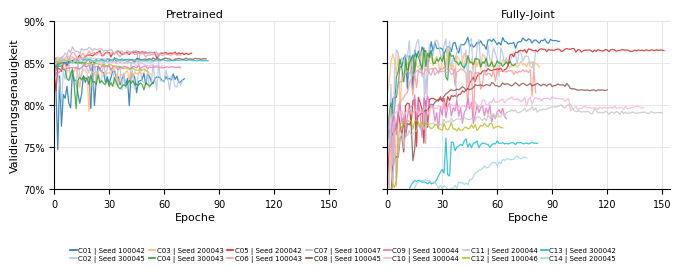

KeyError: "None of [Index(['', '', '', '', '', '', '', '', '', '', '', '', '', ''], dtype='object', name='config_id')] are in the [index]"

In [21]:
plot_metric_variant_pair(
    "val_topk/accuracy",
    "Validierungsgenauigkeit",
    "big_randomsearch_paired14_val_topk_accuracy",
    y_limits=(0.70, 0.90),
    ytick_step=0.05,
)

plot_best_val_topk_paired()


## Trainings- und Hard-Routing-Verläufe


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_train_val_hard_accuracy.pdf


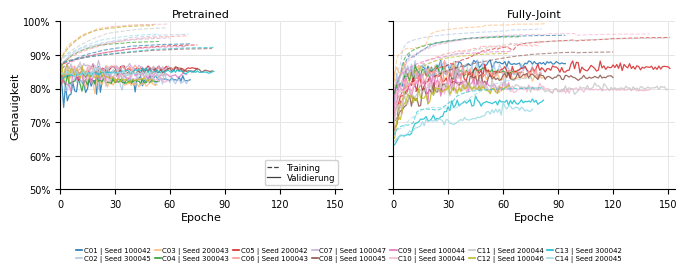

In [ ]:
plot_train_val_variant_pair()


## Routing-Nutzung


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_hard_usage.pdf


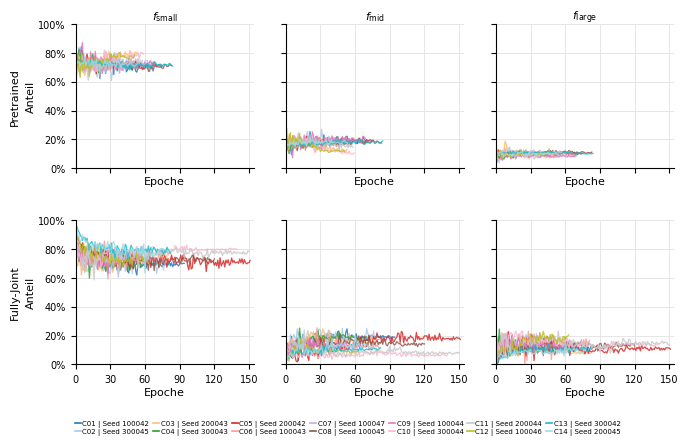

In [ ]:
plot_usage_variant_pair()


## Experten und Mittelwert-Übersicht

Die paarweisen Plots verwenden für identische Konfigurationen jeweils dieselben Farben.


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_expert_accuracy.pdf


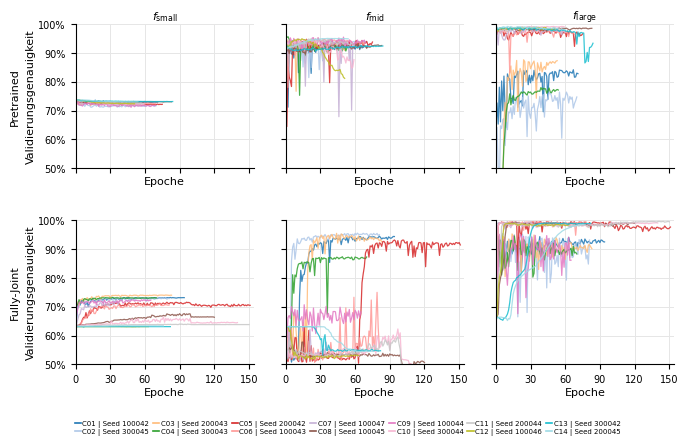

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_topk_accuracy_mean_overview.pdf


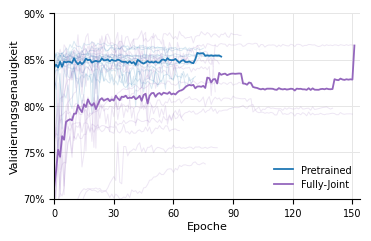

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_budgeted_upper_bound.pdf


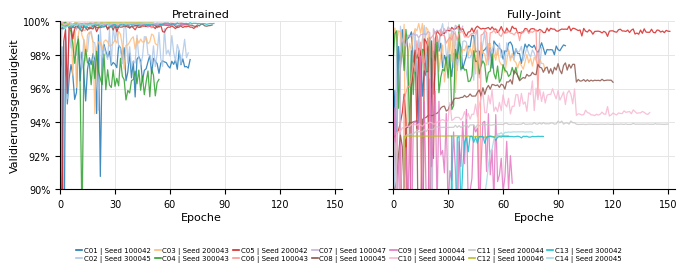

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_budgeted_upper_bound_mean_overview.pdf


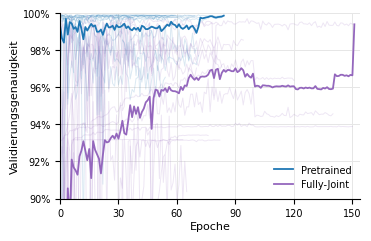

In [ ]:
plot_expert_accuracy_variant_pair()

plot_metric_mean_overview(
    "val_topk/accuracy",
    "Validierungsgenauigkeit",
    "big_randomsearch_paired14_val_topk_accuracy_mean_overview",
    y_limits=(0.70, 0.90),
    ytick_step=0.05,
)

plot_metric_variant_pair(
    "val_budgeted_upper_bound",
    "Validierungsgenauigkeit",
    "big_randomsearch_paired14_val_budgeted_upper_bound",
    y_limits=(0.90, 1.00),
    ytick_step=0.02,
)

plot_metric_mean_overview(
    "val_budgeted_upper_bound",
    "Validierungsgenauigkeit",
    "big_randomsearch_paired14_val_budgeted_upper_bound_mean_overview",
    y_limits=(0.90, 1.00),
    ytick_step=0.02,
)
